In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load cleaned dataset

df = pd.read_csv("../processed/cleaned_youtube_data.csv")

df.head()

,category_id,view_count,like_count,comment_count,duration,duration_seconds
0,0.634019,0.029288,243350.0,-0.330080,PT57S,-0.329112
1,0.017250,-0.319920,3393.0,-0.165235,PT7M50S,0.044432
2,0.634019,2.944978,4178447.0,1.003008,PT47S,-0.338157
3,0.428429,0.524317,909386.0,0.162410,PT31S,-0.352628
4,0.634019,-0.219222,44278.0,-0.138177,PT16S,-0.366195


In [3]:
# Independent variable (Feature)

X = df[["view_count"]]

y = df["like_count"]

print("Feature Head :",X.head())

print("Target Head :",y.head())

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Head :    view_count
0    0.029288
1   -0.319920
2    2.944978
3    0.524317
4   -0.219222
Target Head : 0     243350.0
1       3393.0
2    4178447.0
3     909386.0
4      44278.0
Name: like_count, dtype: float64
Feature Shape : (584, 1)
Target Shape : (584,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 467
Testing Samples : 117


In [5]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [6]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): 329889.8300464218
Intercept: 214225.07850869698


In [7]:
y_pred = model.predict(X_test)

y_pred[:10]

array([120461.43644078, 105232.52888293, 127550.39018138, 119205.8446226 ,
       104910.24574874, 158060.51553458, 448097.58960819, 105417.36812999,
       111384.77337559, 110691.43026818])

In [8]:
#MODEL EVALUATION

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 196256.61622683355
Mean Squared Error : 205870651694.45715
Root Mean Squared Error : 453729.71215742215
R² Score : 0.5340748419207962


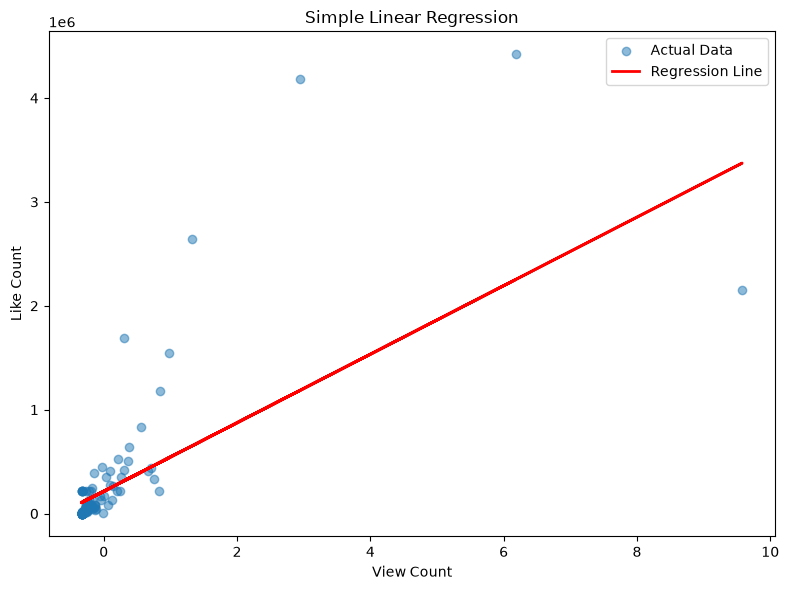

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.5,
    label="Actual Data"
)

plt.plot(
    X_test,
    y_pred,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("View Count")

plt.ylabel("Like Count")

plt.title("Simple Linear Regression")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../images/simple_linear_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,11696.000000,120461.436441
1,183.000000,105232.528883
2,20528.000000,127550.390181
3,50566.000000,119205.844623
4,18.000000,104910.245749
5,45260.000000,158060.515535
6,434811.000000,448097.589608
7,217464.608379,105417.368130
8,15665.000000,111384.773376
9,1973.000000,110691.430268


In [11]:
import os
import joblib

# Create the models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the model
joblib.dump(model, "../models/simple_linear_regression.pkl")

print("Model saved successfully.")

Model saved successfully.


# Conclusion

A Simple Linear Regression model was trained using Video Duration as the only predictor for Average View Percentage.

### Model Performance

Mean Absolute Error : 196256.61622683355
Mean Squared Error : 205870651694.45715
Root Mean Squared Error : 453729.71215742215
R² Score : 0.5340748419207962

### INTERPRETATION

Unlike our previous dataset (where the R² was close to 0 or even negative), this dataset shows a moderately strong linear relationship.

An R² of 0.534 means:

Approximately 53.4% of the variation in a video's like count can be explained solely by its view count.

This is actually a reasonable result because:

More views generally lead to more likes.
But likes are also influenced by factors such as content quality, audience engagement, upload timing, and channel popularity.
